In [35]:
import os
if os.getcwd()[-11:] == "exploration":
    os.chdir('..')
import data.involcan.pull

### Find sensors of interest

In [36]:
import pandas as pd

files = pd.read_csv("data/involcan/metadata/available_files.csv")

In [37]:
# from datetime import datetime
starttime = pd.Timestamp('2021-09-12', tz='UTC')
endtime = pd.Timestamp('2021-09-26', tz='UTC')


files['start_time'] = pd.to_datetime(files['start_time'], utc=True)
files['end_time'] = pd.to_datetime(files['end_time'], utc=True)


eruption_files = files[(files['start_time']==starttime) | (files['end_time']==endtime) ]
eruption_sensors = pd.unique(eruption_files['sensor']).tolist()

In [38]:
print(f"There were {len(eruption_sensors)} measuring during the eruption")
print(f"They were: \n {eruption_sensors}")

There were 18 measuring during the eruption
They were: 
 ['PGAR', 'PBBA', 'PPMA', 'PMLU', 'PLPI', 'PTAB', 'PCOR', 'PA03', 'PA00', 'PA05', 'PA09', 'PA01', 'PA04', 'PA02', 'PA08', 'PA06', 'PA07', 'PSAB']


In [39]:
sensors = pd.read_csv("data/involcan/metadata/stations_all.dat", sep=r"\s+",names=["station", "lat", "lon", "height"])
sensors_lp = sensors[
    ((sensors['lat']<28.871164) & (sensors['lat']>28.437932)) &
    ((sensors['lon']<-17.666590) & (sensors['lon']>-18.039439))
]


In [40]:
from shapely.geometry import Point, Polygon

polygon_coords = [[-18.043671,28.436091],[-18.043671,28.879552],
                  [-17.704468,28.879552],[-17.704468,28.436091],]
polygon = Polygon(polygon_coords)

point = Point(-17.888489,28.694202)
polygon.contains(point)

def is_inside(row, polygon):
    point = Point(row['lon'], row['lat'])  # Importante: (x, y) = (lon, lat)
    return polygon.contains(point)

sensors_lp = sensors[sensors.apply(is_inside, axis=1, args = (polygon,))]

### Download the files of interest

In [41]:
from datetime import datetime, timedelta
starttime = datetime(2021, 9, 15)
endtime = datetime(2021, 9, 25)
# endtime = datetime(2021, 12, 14)
data_path = "/SCRATCH/TIC270/dvalesp/data/involcan/mseed/eruption/"
# data_path = "data/involcan/mseed/"
channels = ["HHE", "HHN", "HHZ"]
# channels = ["HHE"]
sensors = eruption_sensors

data.involcan.pull.download_files(starttime, endtime, sensors, channels, data_path, user='seiscomp', verbose=True);

Connecting to 193.147.109.7...
Connected to 193.147.109.7.
Process completed. Total time: 0:11:11.773618
483 successful downloads. 0 failed downloads.


#### Discarded sensors:
- PGAR: File missing data
- PBBA: File missing data
- PA03: Missing data before the 18th of september
- PA00: Missing data before the 19th of september
- PA05: Missing data in the period of interest
- PA09: Missing data in the period of interest
- PA01: Missing data in the period of interest
- PA04: Missing data in the period of interest
- PA02: Missing data in the period of interest
- PA08: Missing data in the period of interest
- PA06: Missing data in the period of interest
- PA07: Missing data in the period of interest
- PSAB: No data in the period of interest


### Analyze the data

In [42]:
import obspy
from obspy.core import UTCDateTime
import numpy as np


ST = []
sensors = ['PPMA', 'PMLU', 'PLPI']
# sensors = ["PPMA"]
channels = ["HHE", "HHN", "HHZ"]
# channels = ["HHE"]
# sensors = ['PPMA', 'PLPI']

sensor_ids = [eruption_sensors.index(element) for element in sensors if element in eruption_sensors]

for sensor_id in sensor_ids:
    print(f"Reading 2021 data for sensor {eruption_sensors[sensor_id]}...")
    st = obspy.read(f"{data_path}/C7.{eruption_sensors[sensor_id]}.*.*.*.2021.*",
                    starttime=UTCDateTime(starttime), endtime=UTCDateTime(endtime))
    st.merge()
    # st.plot();
    ST.append(st)



Reading 2021 data for sensor PPMA...


/home/TIC270/gsus/DigiVolcan/installation/miniconda3/envs/lafragua/lib/python3.12/site-packages/obspy/io/mseed/util.py:758: UserWarning: Inconsistent word order.
  warnings.warn(msg, UserWarning)


Reading 2021 data for sensor PMLU...
Reading 2021 data for sensor PLPI...


In [ ]:
# st[0].times('matplotlib')

MemoryError: Unable to allocate 659. MiB for an array with shape (43200001, 2) and data type float64

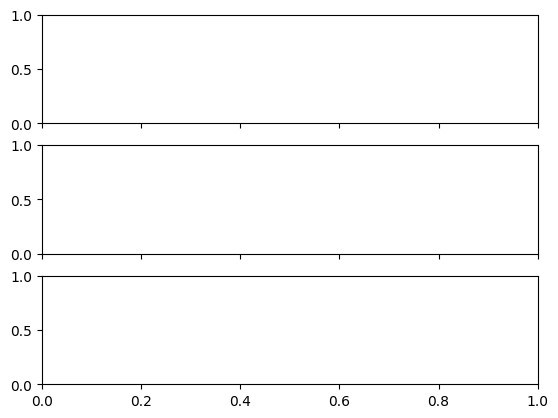

In [ ]:
# import matplotlib.pyplot as plt
# st = ST[2]
# fig, axes = plt.subplots(nrows=len(st), sharex=True)
# for tr, ax in zip(st, axes):
#     times = tr.times('matplotlib')
#     ax.plot(times, tr.data)
# ax.xaxis_date()
# fig.autofmt_xdate()
# # could als use ObsPyAutoDateFormatter on x Axis
# plt.show()

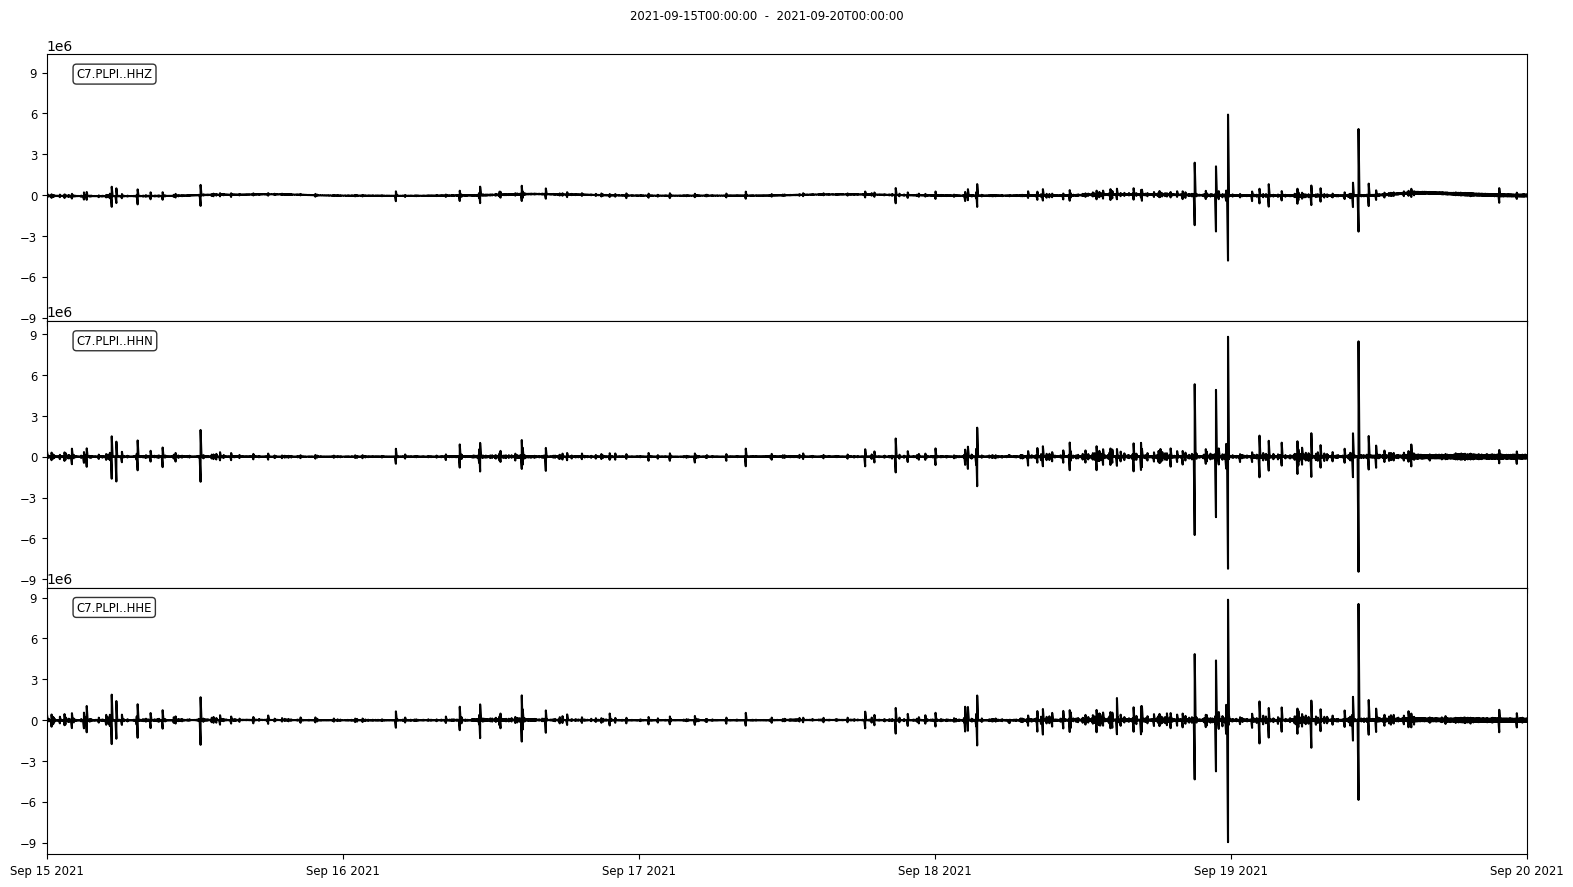

In [ ]:
ST[2].plot(size=(1600,900),);

#### Eliminate calibration pulses

In [43]:
pulses = []
# PPMA pulses:
pulses.append([UTCDateTime(datetime(2021,9,16,16,33,30)), UTCDateTime(datetime(2021,9,16,16, 36,30))])
# st.plot(starttime=UTCDateTime(datetime(2021,9,16,16, 33,30)), endtime=UTCDateTime(datetime(2021,9,16,16, 36,30)));

pulses.append([UTCDateTime(datetime(2021,9,15,6, 51,0)), UTCDateTime(datetime(2021,9,15,6,54,30))])
# st.plot(starttime=UTCDateTime(datetime(2021,9,15,6, 51,0)), endtime=UTCDateTime(datetime(2021,9,15,6,54,30)));



#### Analyze frequencies with MESA

In [44]:
from msa.feature_extraction import features
from msa.visualization import plot

In [45]:
sr = st[0].stats.sampling_rate

window_length = 60 # s
window_samples = int(window_length*sr)
# shift = window_length*1000 #s
shift = 3600 #s
hop = int(shift*sr)

M = len(sensor_ids)
N = len(channels)
times = [[[] for _ in range(N)] for _ in range(M)]
freqs = [[[] for _ in range(N)] for _ in range(M)]
Sxxs  = [[[] for _ in range(N)] for _ in range(M)]

for i, sensor_id in reversed(list(enumerate(sensor_ids))):
    for j, channel in reversed(list(enumerate(channels))):

        signal = ST[i][j].data
        
        if np.ma.is_masked(signal):
            times[i][j] = np.ones_like(time[1:])
            freqs[i][j] = np.ones_like(freq)
            Sxxs[i][j] = np.ones_like(Sxx[:,1:])
        else:
            time, freq, Sxx = features.spectrogram(signal, sr, window_samples, hop, "blackman", "zeros", "linear",)
            times[i][j] = time[1:]
            freqs[i][j] = freq
            Sxxs[i][j]  = Sxx[:,1:]
        print(Sxx.shape, time.shape, freq.shape, i, j)


Sxxs = np.array(Sxxs)
freqs = np.array(freqs)
times = np.array(times)

(3001, 241) (241,) (3001,) 2 2
(3001, 241) (241,) (3001,) 2 1
(3001, 241) (241,) (3001,) 2 0
(3001, 241) (241,) (3001,) 1 2
(3001, 241) (241,) (3001,) 1 1
(3001, 241) (241,) (3001,) 1 0
(3001, 241) (241,) (3001,) 0 2
(3001, 241) (241,) (3001,) 0 1
(3001, 241) (241,) (3001,) 0 0


/home/TIC270/gsus/DigiVolcan/installation/miniconda3/envs/lafragua/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


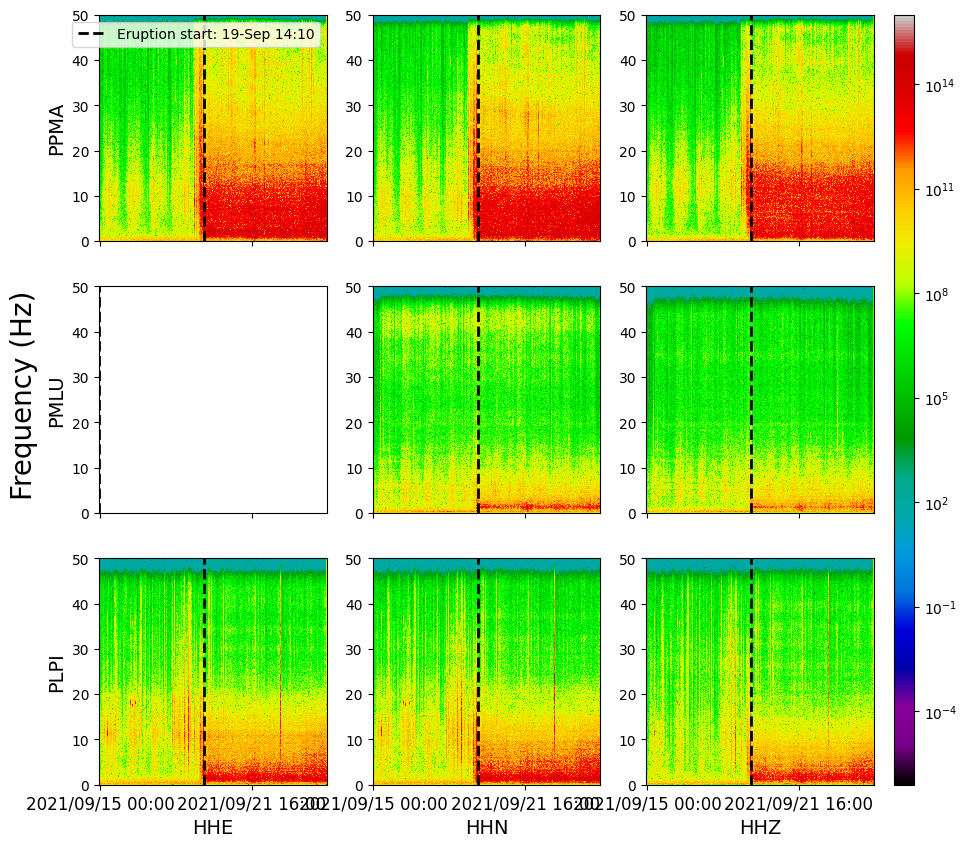

In [46]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# timeUTC = np.linspace(starttime, endtime, num= len(times), endpoint=False, dtype='datetime64[s]')#.astype("datetime64[m]")
timeUTC = np.arange(starttime, endtime, timedelta(seconds=shift), dtype='datetime64[s]')#.astype("datetime64[m]")

target_time = np.datetime64(datetime(2021, 9, 19, 14, 10), 'm')
eruption_idx = np.argmin(np.abs(timeUTC - target_time))

fig, ax = plt.subplots(M,N, figsize=(10,10), sharex=True)
if N == 1: ax = ax[:, np.newaxis]
if M == 1: ax = ax[np.newaxis, :]

vmin = np.min(Sxxs)
vmax = np.max(Sxxs)

if type(ax) != np.ndarray: ax = [ax]

skip:int = int(len(times[0][0])/1.5)
start = 0
locs = times[0][0][start::skip]
timeUTC_label = timeUTC[start::skip]
date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]

for i, sensor in enumerate(sensors):
    for j, channel in enumerate(channels):
        if j == 0: ax[i, j].set_ylabel(f"{sensor}", fontsize = 14)
        if i == len(sensors)-1: ax[i, j].set_xlabel(f"{channel}", fontsize = 14)
        _,_, mesh = plot.spectrogram(times[i,j], freqs[i,j], Sxxs[i,j], cmap="nipy_spectral",
                                    logscale=True, ax = ax[i,j], vmin=vmin, vmax = vmax, ylim=(0,50));


        ax[i,j].set_xticks(locs[:], labels=formatted_labels[:],fontsize=12);

        ax[i,j].axvline(x=times[i,j,eruption_idx], color='black', linestyle='--', linewidth=2, label='Eruption start: 19-Sep 14:10')


ax[0,0].legend();

tbox = ax[ 0,0].get_position()
bbox = ax[-1,0].get_position()
cax = fig.add_axes([0.92, bbox.y0, 0.02, tbox.y1-bbox.y0])
cbar = fig.colorbar(mesh, cax=cax,)

# ax.set_ylabel("Frequency (Hz)", fontsize=20)
fig.text(.05, 0.5, "Frequency (Hz)", ha='center', va='center', rotation=90, fontsize=20);

### PCA Visualizations

#### Normalization of the Sxxs tensor

### Preprocessing

In [47]:
Sxxs.shape, type(Sxxs.shape),times.shape
np.mean(Sxxs, 0).shape

Sxxs[1, 0] = Sxxs[1, 1]


Sxxs_norm = Sxxs
# Mean centering
# Sxxs_norm = Sxxs_norm - np.mean(Sxxs_norm, 0)
# Min max scaling
# Sxxs_norm = (Sxxs_norm - np.min(Sxxs_norm, 0)) / (np.max(Sxxs_norm,0) - np.min(Sxxs_norm,0))
# Max scaling
# Sxxs_norm = (Sxxs_norm) / (np.max(np.abs(Sxxs_norm),0))

vmin = np.min(Sxxs_norm)
vmax = np.max(Sxxs_norm)

vmin, vmax


(np.float64(7.803557288255163e-07), np.float64(1.0009696499541824e+16))

In [48]:
# Data fusion
X = np.vstack(np.vstack(Sxxs_norm)).T
X.shape


(240, 27009)

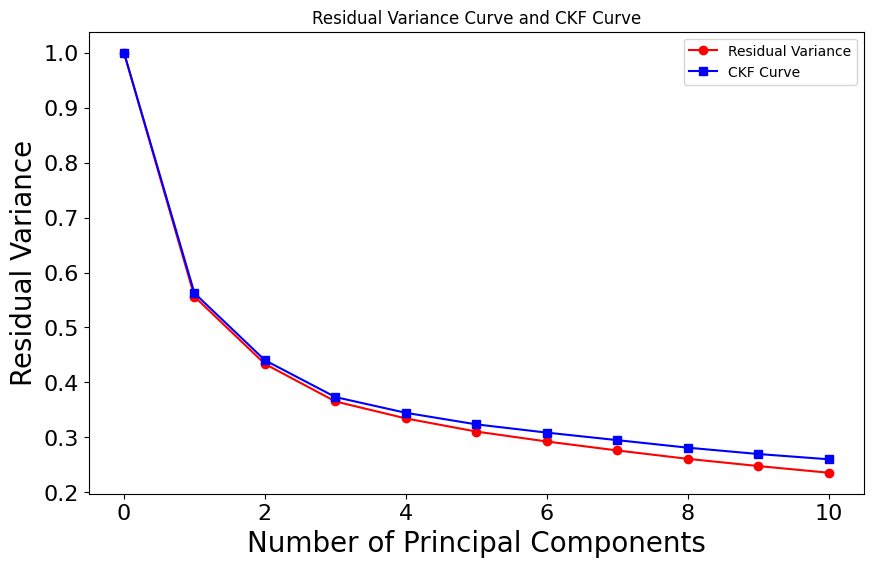

In [49]:
import mspc_pca.plot
mspc_pca.plot.var_pca(X, 10,with_std =False);

In [50]:
# !pip install scikit-learn

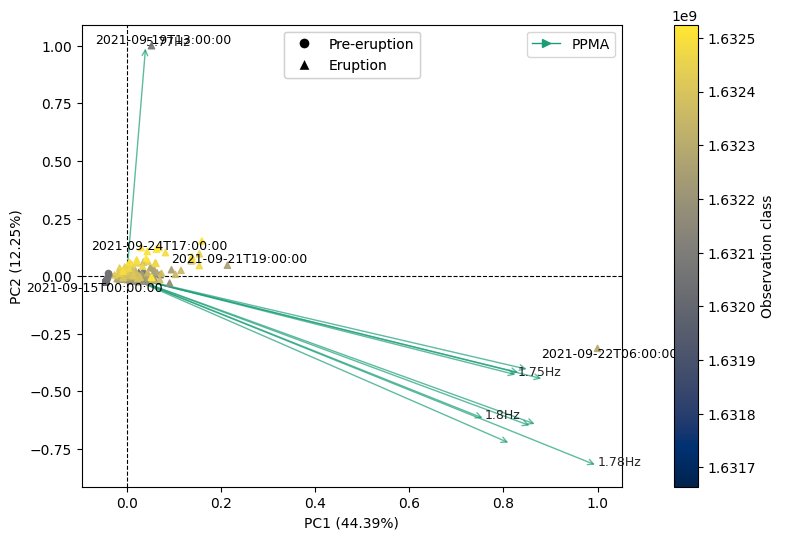

: 

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
PCs=2
pca = PCA(n_components=PCs)


loadings_label = np.array([f"{round(x, 2)}Hz" for x in freqs[0,0]]*M*N) # Add for several sensors 
sensor_class = np.repeat(sensors, freqs[0,0].shape[0]*N)
channel_class = np.repeat(channels, freqs[0,0].shape[0]*M)
# print(channel_class.shape, X.shape)

# time_class = np.hstack([np.repeat('Pre-eruption', eruption_idx-1),
#                         np.repeat('Eruption', len(times[0,0])-eruption_idx+1)])

markers = np.hstack([np.repeat('o', eruption_idx-1),
                     np.repeat('^', len(times[0,0])-eruption_idx+1)])

fig, ax = plt.subplots(1,1, figsize=(9,6))

fig, ax, _ = mspc_pca.plot.biplot(X, pca, 1, 2, timeUTC, np.array(loadings_label),0.15,
                                timeUTC.astype(np.float64), sensor_class.astype(str), loading_percentile = +.5,
                                score_cmap='cividis', loading_cmap='Dark2', markers=markers,
                                ax = ax);

# Legend
legend1 = ax.get_legend()
ax.add_artist(legend1)

legend_elements = [
Line2D([0], [0], marker='o', color='w', label='Pre-eruption',
        markerfacecolor='black', markersize=8),
Line2D([0], [0], marker='^', color='w', label='Eruption',
        markerfacecolor='black', markersize=8)
]

legend2 = ax.legend(handles=legend_elements, loc="upper center")
ax.add_artist(legend2)
plt.show()

In [ ]:
# ST[0].plot(starttime=UTCDateTime(datetime()))

In [52]:
# Mask to see a specific sensor:
sensor = "PPMA"
sensor_id=0
mask = sensor_class == sensor_id

# X=aux
# X_cut = X[:,mask]
# aux = X
# X = X_cut

In [53]:
sensors

['PPMA', 'PMLU', 'PLPI']

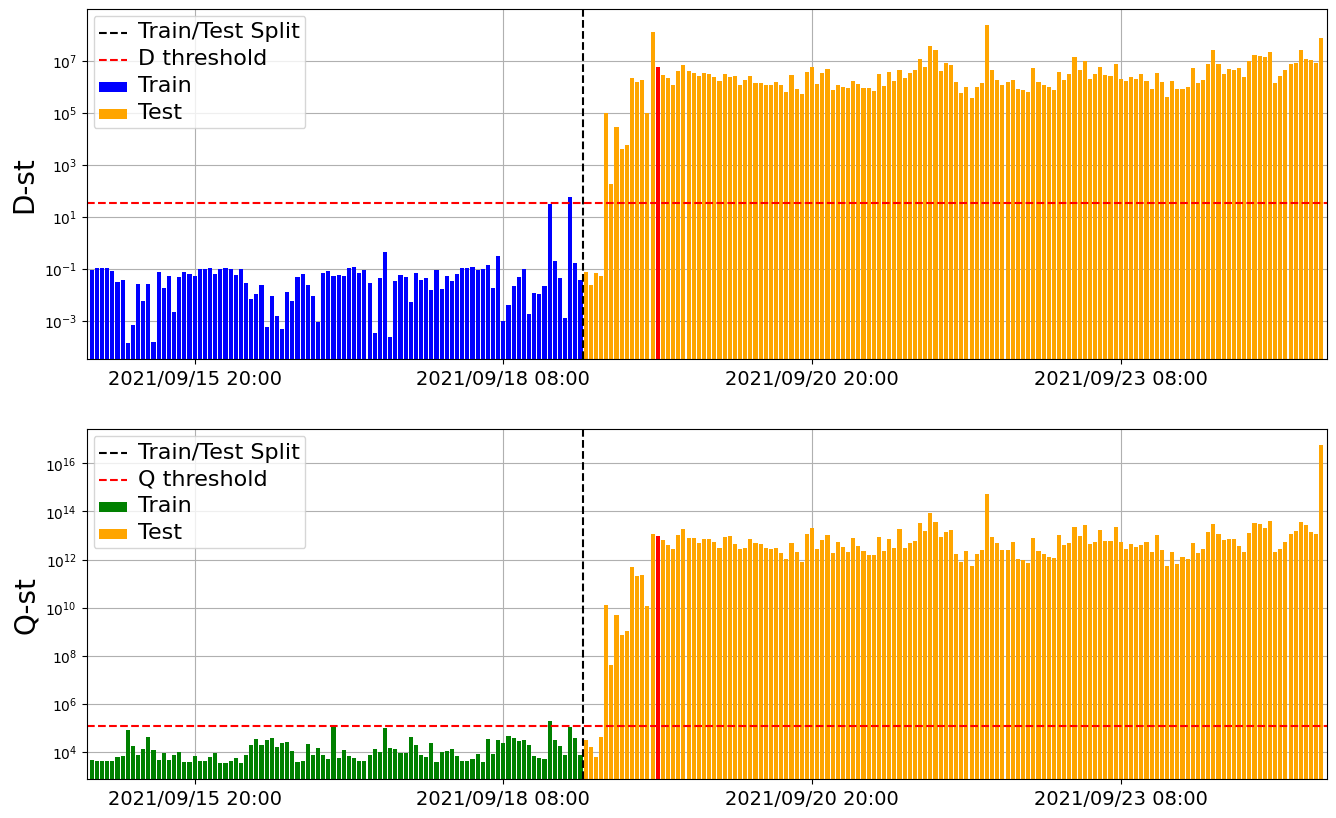

In [54]:
import mspc_pca.mspc
PCs = 1


day_id = np.argmin(np.abs(timeUTC - np.datetime64(datetime(2021, 9, 19), 'm')))

D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q = mspc_pca.mspc.DQ_tt(X[:day_id], X[day_id:], PCs,2, percentile_threshold=True, alpha=0.01)

fig, ax = plt.subplots(2,1, figsize = (16, 10))

ax = ax.tolist()

fig, ax = mspc_pca.mspc.plot_DQ_tt(D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q,
                                   logscale=True, event_index=[eruption_idx], 
                labels=None, plot_train=True, opacity=None, ax=ax)


n_bars = len(Q_train)+len(Q_test)

skip:int = len(timeUTC)//4
start = 20
locs = np.arange(0, n_bars)[start::skip]
timeUTC_label = timeUTC[start::skip]



date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC_label]
ax[0].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);
ax[1].set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);

ax[0].set_ylabel("D-st", fontsize = 20)
ax[0].set_title("")
legend = ax[0].get_legend()
for text in legend.get_texts():
    text.set_fontsize(16) 


ax[1].set_ylabel("Q-st", fontsize = 20)
ax[1].set_title("")
legend = ax[1].get_legend()
for text in legend.get_texts():
    text.set_fontsize(16) 

for axis in ax:
    axis.set_xlim(-1, n_bars)
    axis.grid(which='minor', alpha=0.5,)
    axis.set_axisbelow(True)

In [55]:
from mspc_pca.omeda import omeda
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

# preprocessing = 1
# n_components = 2
logscale = False

# Frequency labels
n_freq = X.shape[1] // len(sensor_ids)
var_labels = np.linspace(0, sr // 2, n_freq)
var_label_ids = [i for i, label in enumerate(var_labels) if label % 10 == 0]
var_labels_str = [str(round(label, 4)) for label in var_labels if label % 10 == 0]
var_classes = []


pca.fit_transform(X)
loadings = pca.components_.T
dummy = - np.ones(len(X))
dummy[:day_id+5] = 1

dummy = -dummy

X_norm = X;


omeda_vec = omeda(testcs=X_norm, dummy=dummy, R=loadings, plot=False)


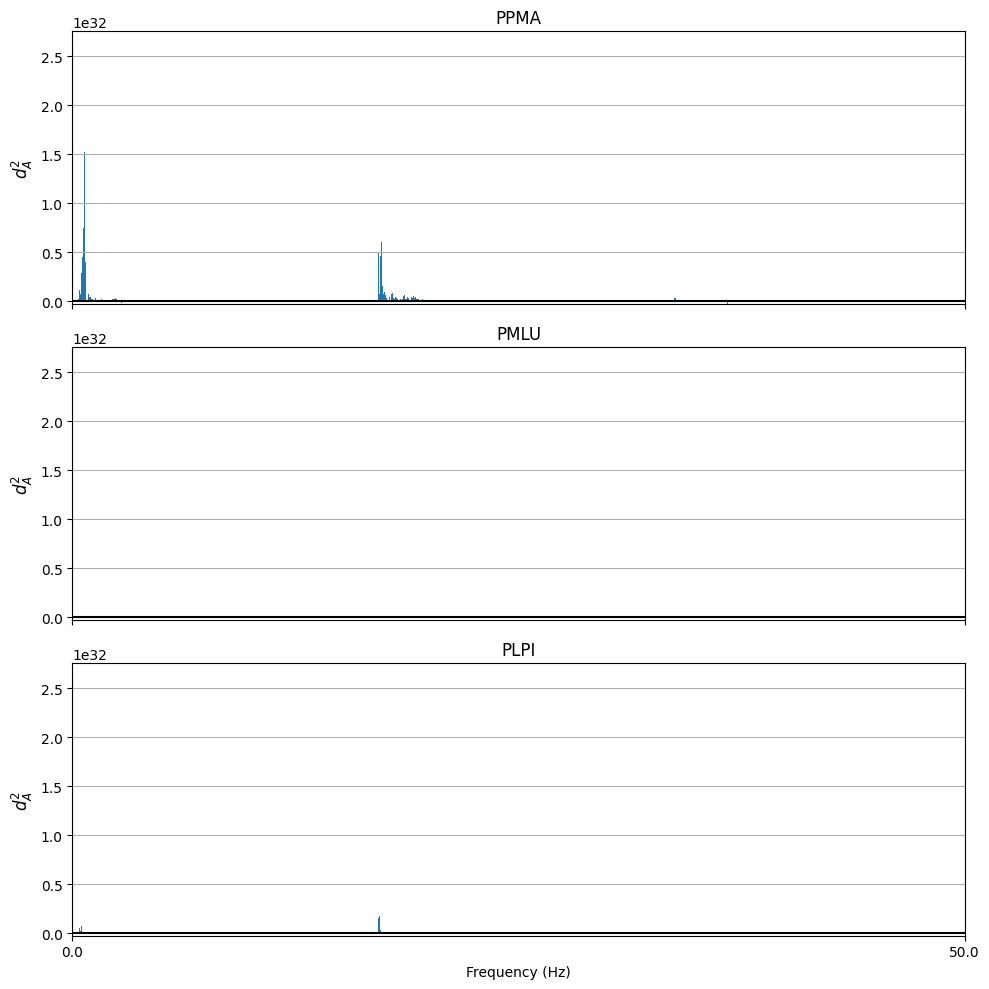

In [56]:

fig, ax = plt.subplots(len(sensor_ids),1, figsize=(10,10), sharex=True)
if type(ax) != np.ndarray: ax = [ax]

for i, sensor_id in enumerate(sensor_ids):
    x = np.arange(len(omeda_vec[i*n_freq : (i+1)*n_freq]))
    ax[i].set_xlim(np.min(x)-1, np.max(x)+1)

    # Handle coloring
    if var_classes:
        unique_classes = np.unique(var_classes)
        cmap = plt.get_cmap('tab10')
        colors = [cmap(i % 10) for i in range(len(unique_classes))]
        class_color_map = dict(zip(unique_classes, colors))
        bar_colors = [class_color_map[cls] for cls in var_classes]

        # Create legend
        patches = [mpatches.Patch(color=color, label=str(cls)) for cls, color in class_color_map.items()]
        ax[i].legend(handles=patches, prop={'size': 10})
    else:
        bar_colors = 'tab:blue'

    ax[i].bar(x, omeda_vec[i*n_freq : (i+1)*n_freq], color=bar_colors)

    ax[i].axhline(0, color='black', linewidth=1.5)  # X-axis

    # Handle variable labels
    if len(var_labels_str) > 0:
        ax[i].set_xticks(var_label_ids)
        label_lengths = [len(str(label)) for label in var_labels]
        rot = 90 if max(label_lengths) > 20 else 0  # rotate if labels are too long
        ax[i].set_xticklabels(var_labels_str, rotation=rot)
        ax[i].tick_params(axis='x', labelsize=10)

    ax[i].set_title(f"{eruption_sensors[sensor_id]}")
    if i == len(sensor_ids) - 1:
        ax[i].set_xlabel("Frequency (Hz)")
    ax[i].set_ylabel('$d^2_A$', fontsize=12)
    ax[i].grid(True)
    # ax[i].set_xlim(0, )
    if logscale:
        ax[i].set_yscale("log")
        ax[i].set_ylim(1, 100 * max(omeda_vec))
    else:
        ax[i].set_ylim(0.8 * np.min(omeda_vec), 1.2 * np.max(omeda_vec))

plt.tight_layout()
plt.show()

In [57]:
np.max(omeda_vec)

np.float64(2.2950216066396024e+32)